# Acrobot Control Workflow

This notebook is the script-based workflow for `compensation_controller/acados_acrobot_swingup.ipynb`. It uses the latest SysID parameter json for the configured `cell_id`, generates an acrobot reference, and can optionally start the hardware NMPC run.

## Flow

1. Load `sysid_config.json`.
2. Select latest `identified_params_{cell}_fit_*.json`.
3. Generate `acrobot_reference_{cell}.npz` with parameter sha256 provenance.
4. Optionally run `ctrl_run_acrobot.py` on hardware.
5. Show latest `ctrlrun_acrobot_{cell}_*.npz` log.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

ROOT = Path.cwd()
if (ROOT / "ctrl_run_acrobot.py").exists():
    CTRL_DIR = ROOT
elif (ROOT / "sysid_pipeline" / "ctrl_run_acrobot.py").exists():
    CTRL_DIR = ROOT / "sysid_pipeline"
else:
    raise FileNotFoundError("Run this notebook from sysid_pipeline or the project root.")

print(f"Control root: {CTRL_DIR}")

Control root: /home/jupyter-venky/underactuated_double_pendulum_package


## Settings

In [2]:
PLANT = "acrobot"

# Generate a fresh reference before hardware control.
MAKE_REFERENCE = True

# Hardware run is off by default. Set True only when the cell is ready.
RUN_HARDWARE = True

T_SIM = 20.0
RECORD = True

# If empty, use the latest identified_params_{cell}_fit_*.json.
PARAM_FILE = None

# Advanced options.
# Leave None to use ACADOS_SOURCE_DIR/ACADOS_ROOT/~/acados.
ACADOS_ROOT = None
ALLOW_IPOPT_FALLBACK = False
ALLOW_LEGACY_REF = False

## Helpers

In [3]:
def run_step(tag, args, check=True):
    cmd = [sys.executable, *map(str, args)]
    print("\n" + "=" * 72)
    print(f"{tag}: {' '.join([Path(sys.executable).name, *map(str, args)])}")
    print("=" * 72, flush=True)
    env = os.environ.copy()
    env.setdefault("PYTHONIOENCODING", "utf-8")
    if globals().get("ACADOS_ROOT"):
        acados_root = str(Path(ACADOS_ROOT).expanduser().resolve())
        env["ACADOS_SOURCE_DIR"] = acados_root
        env["ACADOS_ROOT"] = acados_root
    proc = subprocess.Popen(
        cmd,
        cwd=str(CTRL_DIR),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=env,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()
    print(f"\nexit={rc}")
    if check and rc != 0:
        raise RuntimeError(f"{tag} failed with exit code {rc}")
    return rc


def load_config():
    with (CTRL_DIR / "sysid_config.json").open("r", encoding="utf-8") as f:
        return json.load(f)


def data_root(cfg):
    return (CTRL_DIR / cfg.get("data_dir", ".")).resolve()


def latest_params(cfg):
    if PARAM_FILE:
        p = Path(PARAM_FILE)
        return p if p.is_absolute() else data_root(cfg) / p
    root = data_root(cfg)
    cell = cfg["cell_id"]
    files = sorted(root.glob(f"identified_params_{cell}_fit_*.json"), key=lambda p: p.stat().st_mtime)
    if not files:
        files = sorted(root.glob(f"identified_params_{cell}_*.json"), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError("No identified parameter json found. Run sysid_workflow.ipynb first.")
    return files[-1]


cfg = load_config()
PARAM_PATH = latest_params(cfg)
print(f"cell_id: {cfg['cell_id']}")
print(f"params : {PARAM_PATH.name}")

cell_id: 202
params : identified_params_202_fit_20260721-231023.json


## Generate Reference

In [4]:
if MAKE_REFERENCE:
    run_step(
        "Make acrobot reference",
        ["ctrl_make_reference.py", "--plant", PLANT, "--params", str(PARAM_PATH), "--force"],
    )
else:
    print("Skipping reference generation.")


Make acrobot reference: python ctrl_make_reference.py --plant acrobot --params /home/jupyter-venky/underactuated_double_pendulum_package/identified_params_202_fit_20260721-231023.json --force
params: identified_params_202_fit_20260721-231023.json  sha256=30816c27d60f...

== ACROBOT (elbow-driven) -> acrobot_reference_202.npz ==
  warm start <- /home/jupyter-venky/underactuated_double_pendulum_package/acrobot_reference_202.npz

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

  warm-start solve converged in 72.1s
  [acrobot] defect=9.4e-05 (> 1e-8: IPOPT stopped at acceptable tolerance)  peak_tau1=1.6mNm peak_tau2=96.8mNm  peak|dq|=18.54  terminal|q1-pi|

## Run Hardware Control

This starts a CloudPendulum experiment. Keep `RUN_HARDWARE=False` until the cell, token, and reference are confirmed.

In [5]:
if RUN_HARDWARE:
    args = ["ctrl_run_acrobot.py", "--params", str(PARAM_PATH), "--t-sim", str(T_SIM)]
    if not RECORD:
        args.append("--no-record")
    if ALLOW_IPOPT_FALLBACK:
        args.append("--allow-ipopt-fallback")
    if ALLOW_LEGACY_REF:
        args.append("--allow-legacy-ref")
    run_step("Run acrobot hardware control", args)
else:
    print("RUN_HARDWARE=False; hardware control not started.")


Run acrobot hardware control: python ctrl_run_acrobot.py --params /home/jupyter-venky/underactuated_double_pendulum_package/identified_params_202_fit_20260721-231023.json --t-sim 20.0
== ACROBOT (elbow-driven) | cell_id=202 | token 185...248(len=19) ==
params: identified_params_202_fit_20260721-231023.json  sha256=30816c27d60f...
  reference: loaded acrobot_reference_202.npz  peak|dq|=18.5 peak|tau1|=2mNm peak|tau2|=97mNm
  reference: 150 swing-up + 150 hold steps, dt_ref=20 ms
  preloaded 4/4 acados libraries from /home/jupyter-venky/acados/lib
acados   OK (acados_template.acados_ocp)
Using AcadosTracker (SQP-RTI).
MPC horizon = 18 * 20 ms = 0.36 s | top LQR=False
Compatible DoublePendulum cells: [201, 202, 203, 204]
Requested cell_id = 202
Successfully reserved cell on the server
Livestream url:  http://cloudpendulum.m2.chalmers.se:5080/live/viewer.jsp?host=cloudpendulum.m2.chalmers.se&stream=1166179740191501056
Starting experiment in 5 seconds
Starting experiment in 4 seconds
Start

## Latest Logs

In [6]:
cfg = load_config()
root = data_root(cfg)
cell = cfg["cell_id"]
logs = sorted(root.glob(f"ctrlrun_{PLANT}_{cell}_*.npz"), key=lambda p: p.stat().st_mtime)
if logs:
    print(f"Latest log: {logs[-1].name}")
else:
    print("No hardware log yet.")

refs = sorted(root.glob(f"{PLANT}_reference_{cell}.npz"), key=lambda p: p.stat().st_mtime)
if refs:
    print(f"Reference: {refs[-1].name}")

Latest log: ctrlrun_acrobot_202_20260722-121552.npz
Reference: acrobot_reference_202.npz


## Plots

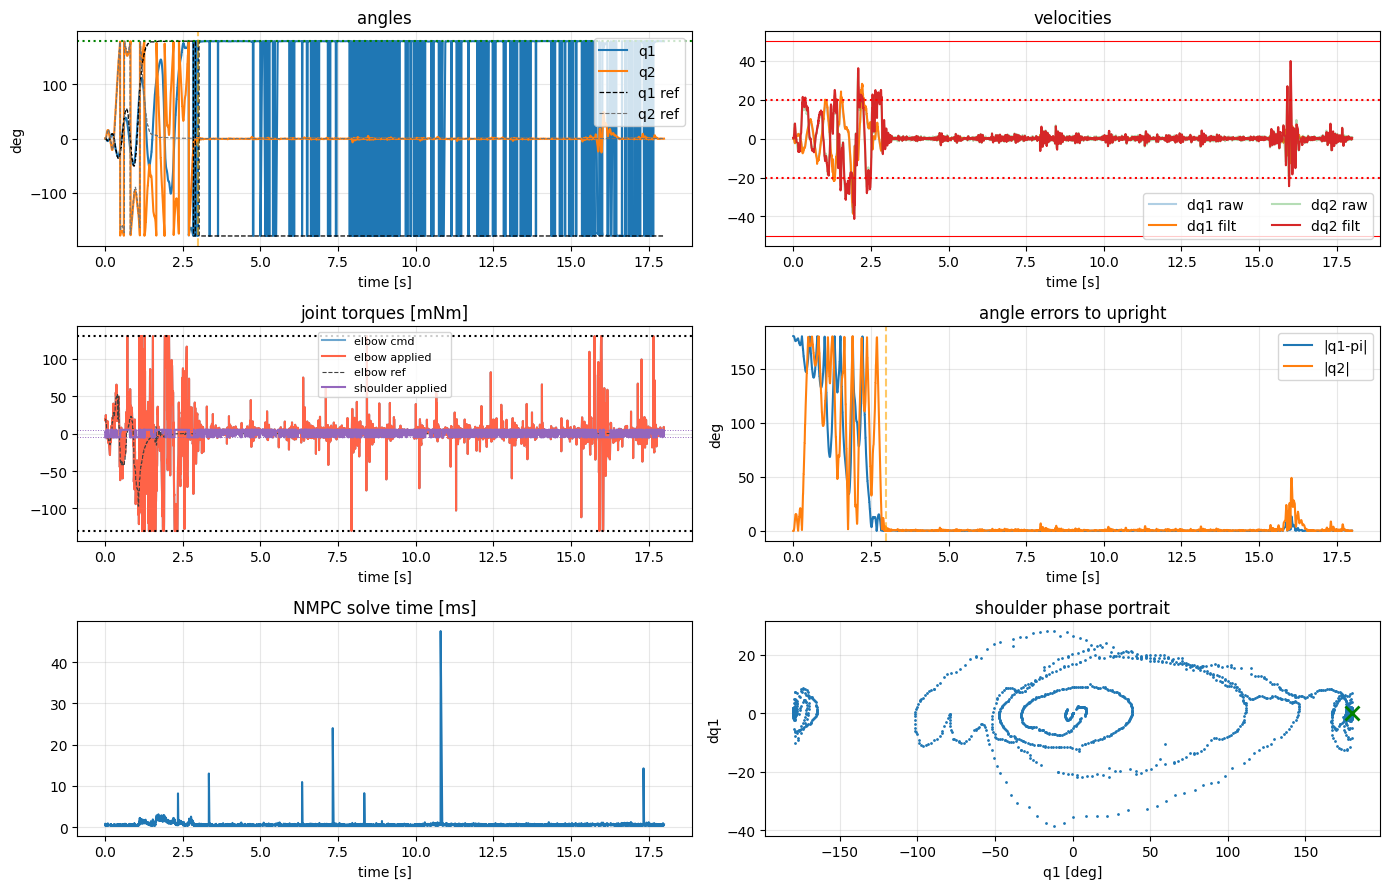

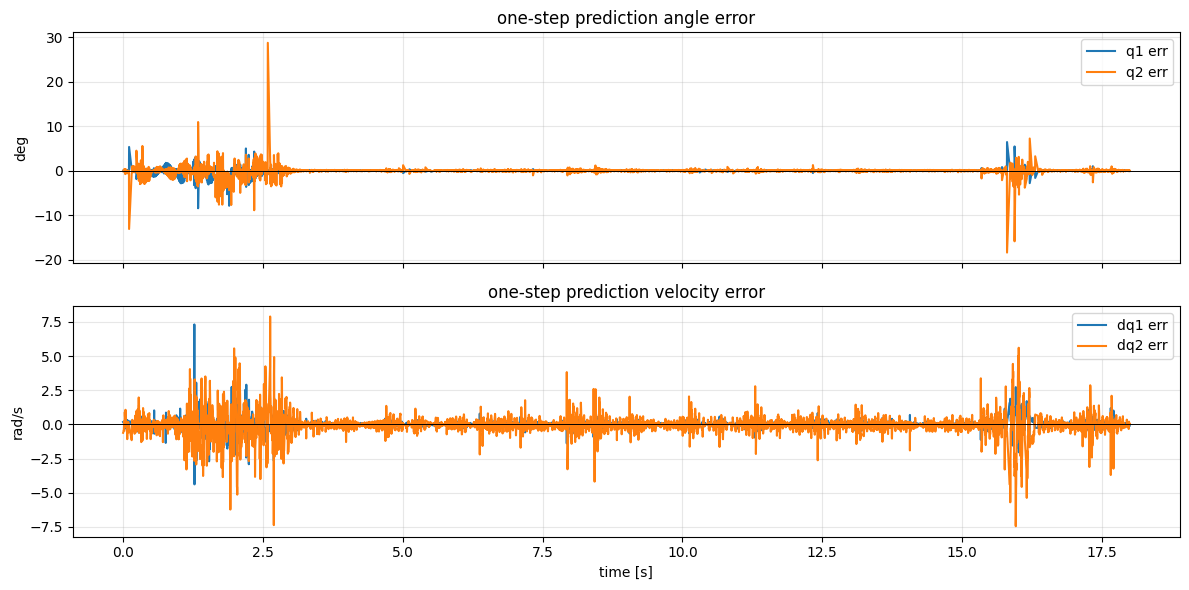

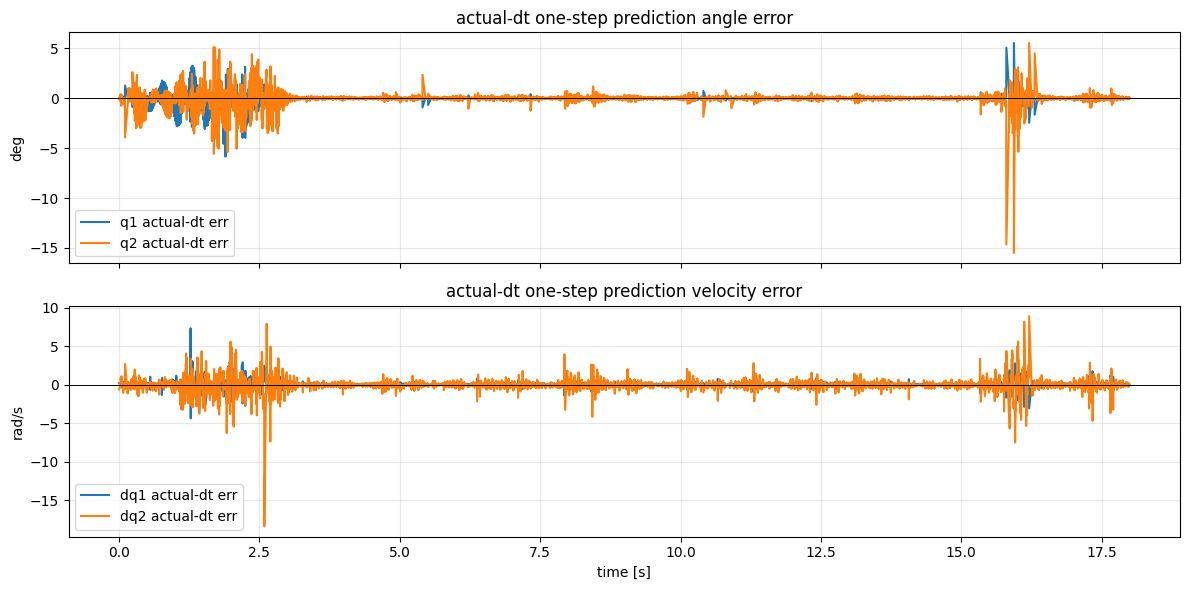

Loading identified parameters for detailed energy / residual plots ...


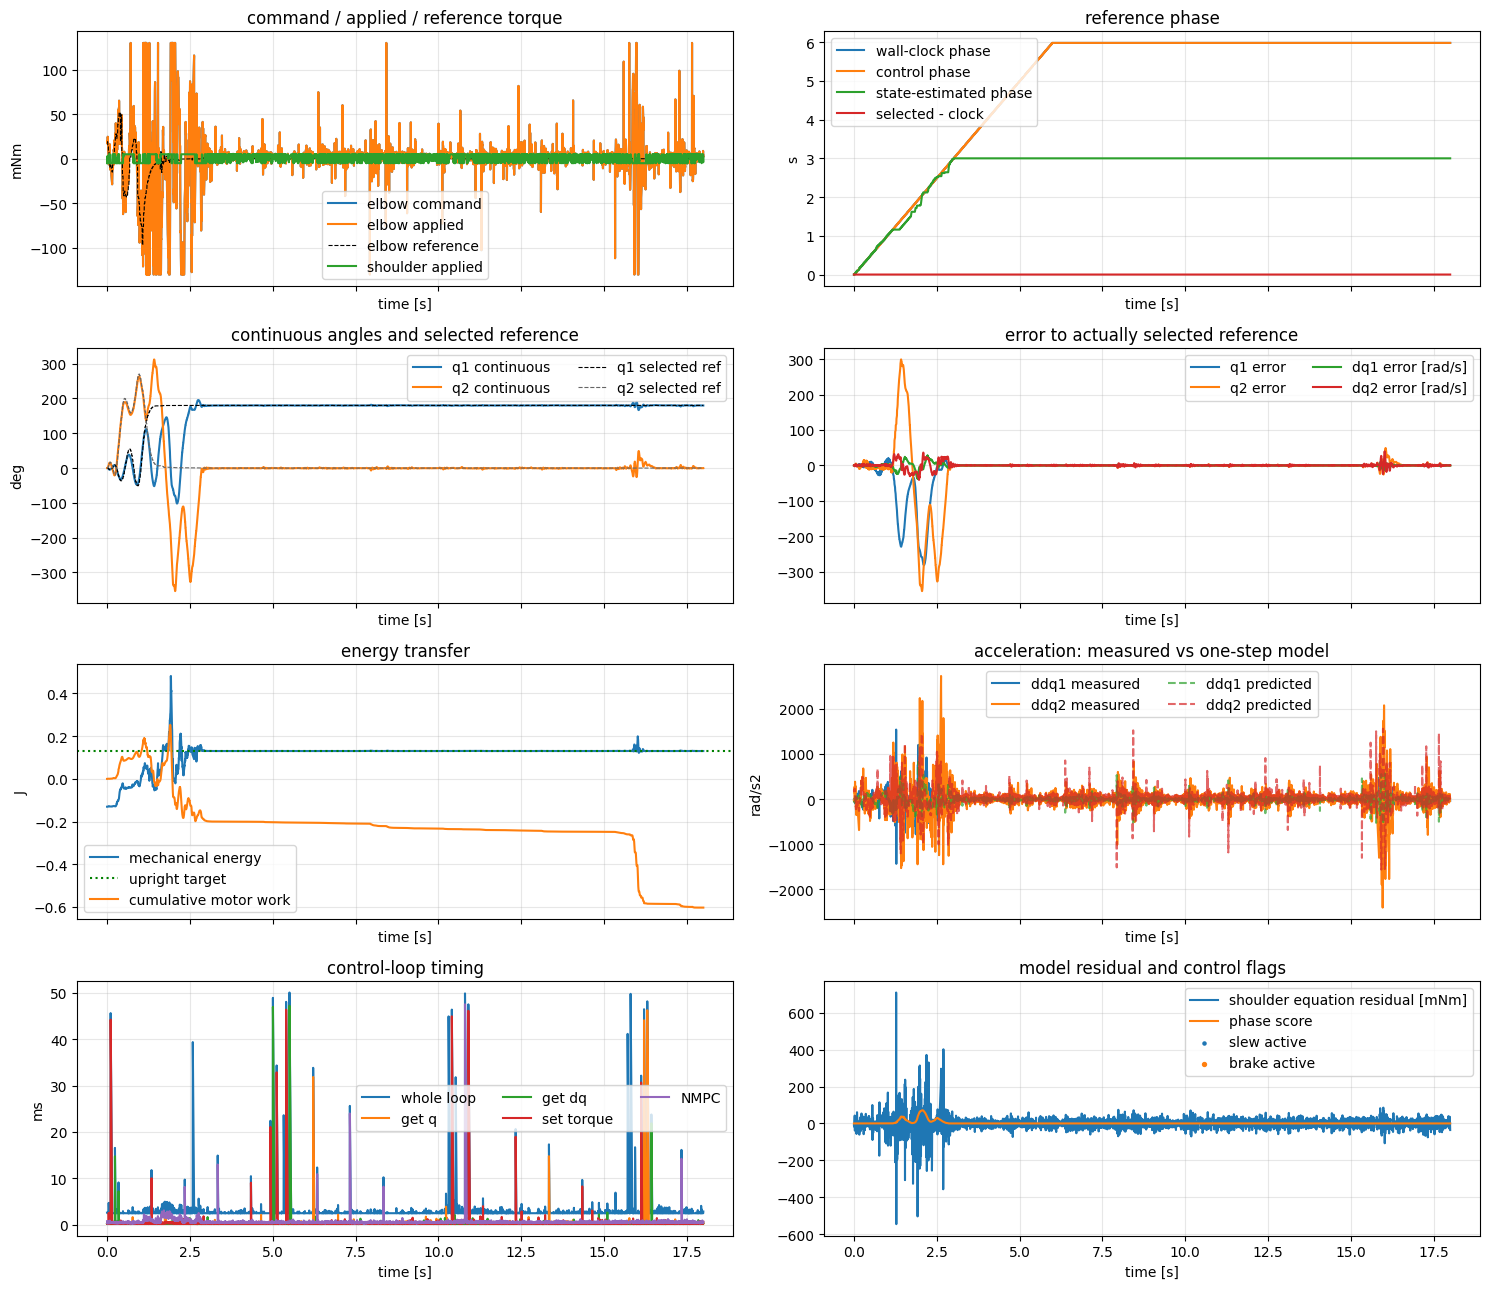

In [7]:
if not logs:
    print("No hardware log to plot yet.")
else:
    import numpy as np
    import matplotlib.pyplot as plt
    import json as _json

    log = np.load(logs[-1])
    n_act = int(log.get('n_act', 0))
    if n_act == 0:
        print("Log exists but contains no control steps.")
    else:
        q_hist = log['q_hist']
        q_unwrapped_hist = log['q_unwrapped_hist']
        dq_hw_hist = log['dq_hw_hist']
        dq_f_hist = log['dq_f_hist']
        tau_hist = log['tau_hist']
        u_cmd_hist = log['u_cmd_hist']
        u_ref_hist = log['u_ref_hist']
        dt_hist = log['dt_hist']
        t_hist = log['t_hist']
        sample_time_hist = log['sample_time_hist']
        x_meas_hist = log['x_meas_hist']
        idx_hist = log['idx_hist']
        idx_time_hist = log['idx_time_hist']
        idx_state_hist = log['idx_state_hist']
        idx_score_hist = log['idx_score_hist']
        idx_gap_hist = log['idx_gap_hist']
        solve_hist = log['solve_hist']
        solver_status_hist = log['solver_status_hist']
        mode_hist = log['mode_hist']
        slew_active_hist = log['slew_active_hist']
        brake_hist = log['brake_hist']
        get_q_time_hist = log['get_q_time_hist']
        get_dq_time_hist = log['get_dq_time_hist']
        set_u_time_hist = log['set_u_time_hist']
        x_pred1_hist = log['x_pred1_hist']
        pred1_err_hist = log['pred1_err_hist']
        x_pred1_actualdt_hist = log['x_pred1_actualdt_hist']
        pred1_actualdt_err_hist = log['pred1_actualdt_err_hist']
        Xref = log['Xref']
        Uref = log['Uref']

        TAU1_MAX = float(log.get('TAU1_MAX', 0.005))
        TAU_MAX = float(log.get('TAU_MAX', 0.13))
        DQ_LIMIT = float(log.get('DQ_LIMIT', 20.0))
        DQ_ABORT = float(log.get('DQ_ABORT', 50.0))
        N_SWINGUP = int(log.get('N_SWINGUP', 150))
        NTOT = int(log.get('NTOT', 300))
        dt_ref = float(log.get('dt_ref', 0.02))
        N_MPC = int(log.get('N_MPC', 18))

        def wrap(a): return (a + np.pi) % (2*np.pi) - np.pi

        T_t = sample_time_hist[:n_act]
        t_sw = N_SWINGUP * dt_ref

        # ---- 3x2 overview grid ----
        fig, axs = plt.subplots(3, 2, figsize=(14, 9), sharex=False)
        axs = axs.ravel()

        ax = axs[0]
        ax.plot(T_t, np.degrees(wrap(q_hist[1:n_act + 1, 0])), label='q1')
        ax.plot(T_t, np.degrees(wrap(q_hist[1:n_act + 1, 1])), label='q2')
        sel_ref = Xref[:, np.clip(idx_hist[:n_act], 0, NTOT)]
        ax.plot(T_t, np.degrees(wrap(sel_ref[0])), 'k--', lw=.9, label='q1 ref')
        ax.plot(T_t, np.degrees(wrap(sel_ref[1])), color='0.45', ls='--', lw=.8, label='q2 ref')
        ax.axhline(180, ls=':', c='g')
        ax.axvline(t_sw, ls='--', c='orange', alpha=.6)
        ax.set_ylabel('deg'); ax.set_title('angles')
        ax.legend(); ax.grid(alpha=.3)

        ax = axs[1]
        ax.plot(T_t, dq_hw_hist[:n_act, 0], alpha=.35, label='dq1 raw')
        ax.plot(T_t, dq_f_hist[:n_act, 0], label='dq1 filt')
        ax.plot(T_t, dq_hw_hist[:n_act, 1], alpha=.35, label='dq2 raw')
        ax.plot(T_t, dq_f_hist[:n_act, 1], label='dq2 filt')
        ax.axhline(DQ_LIMIT, ls=':', c='r'); ax.axhline(-DQ_LIMIT, ls=':', c='r')
        ax.axhline(DQ_ABORT, ls='-', c='r', lw=.8); ax.axhline(-DQ_ABORT, ls='-', c='r', lw=.8)
        ax.set_title('velocities')
        ax.legend(ncol=2); ax.grid(alpha=.3)

        ax = axs[2]
        ax.plot(T_t, u_cmd_hist[:n_act, 1] * 1e3, c='tab:blue', alpha=.65, label='elbow cmd')
        ax.plot(T_t, tau_hist[:n_act, 1] * 1e3, c='tomato', label='elbow applied')
        ax.plot(T_t, u_ref_hist[:n_act, 1] * 1e3, c='0.25', ls='--', lw=.8, label='elbow ref')
        ax.plot(T_t, tau_hist[:n_act, 0] * 1e3, c='tab:purple', label='shoulder applied')
        ax.axhline(TAU_MAX * 1e3, ls=':', c='k'); ax.axhline(-TAU_MAX * 1e3, ls=':', c='k')
        ax.axhline(TAU1_MAX * 1e3, ls=':', c='tab:purple', lw=.7)
        ax.axhline(-TAU1_MAX * 1e3, ls=':', c='tab:purple', lw=.7)
        ax.set_title('joint torques [mNm]')
        ax.legend(fontsize=8); ax.grid(alpha=.3)

        ax = axs[3]
        q1e = np.degrees(np.abs(wrap(q_hist[1:n_act + 1, 0] - np.pi)))
        q2e = np.degrees(np.abs(wrap(q_hist[1:n_act + 1, 1])))
        ax.plot(T_t, q1e, label='|q1-pi|')
        ax.plot(T_t, q2e, label='|q2|')
        ax.axvline(t_sw, ls='--', c='orange', alpha=.6)
        ax.set_title('angle errors to upright'); ax.set_ylabel('deg')
        ax.legend(); ax.grid(alpha=.3)

        ax = axs[4]
        ax.plot(T_t, solve_hist[:n_act] * 1e3)
        ax.set_title('NMPC solve time [ms]'); ax.grid(alpha=.3)

        ax = axs[5]
        ax.plot(np.degrees(wrap(q_hist[1:n_act + 1, 0])), dq_f_hist[:n_act, 0], '.', ms=2)
        ax.plot([180], [0], 'gx', ms=10, mew=2)
        ax.set_xlabel('q1 [deg]'); ax.set_ylabel('dq1')
        ax.set_title('shoulder phase portrait'); ax.grid(alpha=.3)

        for ax in axs[:5]:
            ax.set_xlabel('time [s]')
        plt.tight_layout(); plt.show()

        # ---- One-step prediction errors ----
        if n_act > 1:
            valid_pred = np.all(np.isfinite(pred1_err_hist[:n_act]), axis=1)
            if np.any(valid_pred):
                tt = T_t[valid_pred]
                e = pred1_err_hist[:n_act][valid_pred]
                fig2, ax2 = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
                ax2[0].plot(tt, np.degrees(e[:, 0]), label='q1 err')
                ax2[0].plot(tt, np.degrees(e[:, 1]), label='q2 err')
                ax2[0].axhline(0, c='k', lw=.7)
                ax2[0].set_ylabel('deg')
                ax2[0].set_title('one-step prediction angle error')
                ax2[0].legend(); ax2[0].grid(alpha=.3)
                ax2[1].plot(tt, e[:, 2], label='dq1 err')
                ax2[1].plot(tt, e[:, 3], label='dq2 err')
                ax2[1].axhline(0, c='k', lw=.7)
                ax2[1].set_ylabel('rad/s'); ax2[1].set_xlabel('time [s]')
                ax2[1].set_title('one-step prediction velocity error')
                ax2[1].legend(); ax2[1].grid(alpha=.3)
                plt.tight_layout(); plt.show()

            valid_pred_a = np.all(np.isfinite(pred1_actualdt_err_hist[:n_act]), axis=1)
            if np.any(valid_pred_a):
                tt = T_t[valid_pred_a]
                ea = pred1_actualdt_err_hist[:n_act][valid_pred_a]
                fig3, ax3 = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
                ax3[0].plot(tt, np.degrees(ea[:, 0]), label='q1 actual-dt err')
                ax3[0].plot(tt, np.degrees(ea[:, 1]), label='q2 actual-dt err')
                ax3[0].axhline(0, c='k', lw=.7)
                ax3[0].set_ylabel('deg')
                ax3[0].set_title('actual-dt one-step prediction angle error')
                ax3[0].legend(); ax3[0].grid(alpha=.3)
                ax3[1].plot(tt, ea[:, 2], label='dq1 actual-dt err')
                ax3[1].plot(tt, ea[:, 3], label='dq2 actual-dt err')
                ax3[1].axhline(0, c='k', lw=.7)
                ax3[1].set_ylabel('rad/s'); ax3[1].set_xlabel('time [s]')
                ax3[1].set_title('actual-dt one-step prediction velocity error')
                ax3[1].legend(); ax3[1].grid(alpha=.3)
                plt.tight_layout(); plt.show()

        # ---- Detailed diagnostics (requires identified params) ----
        if n_act > 2:
            print("Loading identified parameters for detailed energy / residual plots ...")
            with open(PARAM_PATH, 'r', encoding='utf-8') as f:
                P = _json.load(f)
            P1 = P['P1']; P2 = P['P2']; P3 = P['P3']
            P6 = P.get('P6', P['P3'])
            P4 = P['P4']; P5 = P['P5']
            b1 = P['b1']; b2 = P['b2']
            cf1 = P['cf1']; cf2 = P['cf2']
            d1 = P.get('d1', 0.0); d2 = P.get('d2', 0.0)
            EPS_VEL = P.get('eps', 0.05)

            q_u = q_unwrapped_hist[1:n_act + 1]
            ref_sel = Xref[:, np.clip(idx_hist[:n_act], 0, NTOT)]
            ref_phase = idx_hist[:n_act] * dt_ref
            state_phase = idx_state_hist[:n_act] * dt_ref
            time_phase = idx_time_hist[:n_act] * dt_ref
            phase_lag = ref_phase - time_phase

            q1 = q_u[:, 0]; q2 = q_u[:, 1]
            dq1 = dq_f_hist[:n_act, 0]; dq2 = dq_f_hist[:n_act, 1]

            M11 = P1 + 2 * P2 * np.cos(q2)
            M12 = P3 + P2 * np.cos(q2)
            kinetic = 0.5 * (M11 * dq1**2 + 2 * M12 * dq1 * dq2 + P6 * dq2**2)
            potential = -P4 * np.cos(q1) - P5 * np.cos(q1 + q2)
            energy = kinetic + potential
            energy_goal = P4 + P5
            motor_power = tau_hist[:n_act, 0] * dq1 + tau_hist[:n_act, 1] * dq2
            motor_work = np.cumsum(motor_power * dt_hist[:n_act])

            ddq_meas = np.column_stack([np.gradient(dq1, T_t), np.gradient(dq2, T_t)])
            valid_ddq = (
                np.all(np.isfinite(x_pred1_actualdt_hist[:n_act]), axis=1)
                & (dt_hist[:n_act] > 1e-5)
            )
            ddq_pred = np.full_like(ddq_meas, np.nan)
            ddq_pred[valid_ddq] = (
                (x_pred1_actualdt_hist[:n_act, 2:][valid_ddq]
                 - dq_f_hist[:n_act][valid_ddq])
                / dt_hist[:n_act][valid_ddq, None]
            )

            h = P2 * np.sin(q2)
            c1 = -2 * h * dq2 * dq1 - h * dq2**2
            g1 = P4 * np.sin(q1) + P5 * np.sin(q1 + q2)
            f1 = (b1 * dq1 + cf1 * np.tanh(dq1 / EPS_VEL)
                  + d1 * dq1 * np.sqrt(dq1**2 + 0.25))
            shoulder_residual = (
                M11 * ddq_meas[:, 0] + M12 * ddq_meas[:, 1]
                + c1 + g1 + f1 - tau_hist[:n_act, 0]
            )

            fig4, ax4 = plt.subplots(4, 2, figsize=(15, 13), sharex=True)
            ax4 = ax4.ravel()

            ax4[0].plot(T_t, u_cmd_hist[:n_act, 1] * 1e3, label='elbow command')
            ax4[0].plot(T_t, tau_hist[:n_act, 1] * 1e3, label='elbow applied')
            ax4[0].plot(T_t, u_ref_hist[:n_act, 1] * 1e3, 'k--', lw=.8, label='elbow reference')
            ax4[0].plot(T_t, tau_hist[:n_act, 0] * 1e3, label='shoulder applied')
            ax4[0].set_ylabel('mNm')
            ax4[0].set_title('command / applied / reference torque'); ax4[0].legend()

            ax4[1].plot(T_t, time_phase, label='wall-clock phase')
            ax4[1].plot(T_t, ref_phase, label='control phase')
            ax4[1].plot(T_t, state_phase, label='state-estimated phase')
            ax4[1].plot(T_t, phase_lag, label='selected - clock')
            ax4[1].set_ylabel('s'); ax4[1].set_title('reference phase'); ax4[1].legend()

            ax4[2].plot(T_t, np.degrees(q_u[:, 0]), label='q1 continuous')
            ax4[2].plot(T_t, np.degrees(q_u[:, 1]), label='q2 continuous')
            ax4[2].plot(T_t, np.degrees(ref_sel[0]), 'k--', lw=.8, label='q1 selected ref')
            ax4[2].plot(T_t, np.degrees(ref_sel[1]), color='0.4', ls='--', lw=.8, label='q2 selected ref')
            ax4[2].set_ylabel('deg')
            ax4[2].set_title('continuous angles and selected reference'); ax4[2].legend(ncol=2)

            ax4[3].plot(T_t, np.degrees(q_u[:, 0] - ref_sel[0]), label='q1 error')
            ax4[3].plot(T_t, np.degrees(q_u[:, 1] - ref_sel[1]), label='q2 error')
            ax4[3].plot(T_t, dq1 - ref_sel[2], label='dq1 error [rad/s]')
            ax4[3].plot(T_t, dq2 - ref_sel[3], label='dq2 error [rad/s]')
            ax4[3].set_title('error to actually selected reference'); ax4[3].legend(ncol=2)

            ax4[4].plot(T_t, energy, label='mechanical energy')
            ax4[4].axhline(energy_goal, c='g', ls=':', label='upright target')
            ax4[4].plot(T_t, motor_work, label='cumulative motor work')
            ax4[4].set_ylabel('J'); ax4[4].set_title('energy transfer'); ax4[4].legend()

            ax4[5].plot(T_t, ddq_meas[:, 0], label='ddq1 measured')
            ax4[5].plot(T_t, ddq_meas[:, 1], label='ddq2 measured')
            ax4[5].plot(T_t, ddq_pred[:, 0], '--', alpha=.7, label='ddq1 predicted')
            ax4[5].plot(T_t, ddq_pred[:, 1], '--', alpha=.7, label='ddq2 predicted')
            ax4[5].set_ylabel('rad/s2')
            ax4[5].set_title('acceleration: measured vs one-step model'); ax4[5].legend(ncol=2)

            ax4[6].plot(T_t, dt_hist[:n_act] * 1e3, label='whole loop')
            ax4[6].plot(T_t, get_q_time_hist[:n_act] * 1e3, label='get q')
            ax4[6].plot(T_t, get_dq_time_hist[:n_act] * 1e3, label='get dq')
            ax4[6].plot(T_t, set_u_time_hist[:n_act] * 1e3, label='set torque')
            ax4[6].plot(T_t, solve_hist[:n_act] * 1e3, label='NMPC')
            ax4[6].set_ylabel('ms'); ax4[6].set_title('control-loop timing'); ax4[6].legend(ncol=3)

            ax4[7].plot(T_t, shoulder_residual * 1e3, label='shoulder equation residual [mNm]')
            ax4[7].plot(T_t, idx_score_hist[:n_act], label='phase score')
            ax4[7].scatter(
                T_t[slew_active_hist[:n_act]],
                np.zeros(np.sum(slew_active_hist[:n_act])), s=5, label='slew active'
            )
            ax4[7].scatter(
                T_t[brake_hist[:n_act]],
                np.ones(np.sum(brake_hist[:n_act])), s=8, label='brake active'
            )
            ax4[7].set_title('model residual and control flags'); ax4[7].legend()

            for ax in ax4:
                ax.grid(alpha=.3); ax.set_xlabel('time [s]')
            plt.tight_layout(); plt.show()